 Task 2: Short-Term Stock Price Prediction
Internship: AI/ML Engineering - DevelopersHub Corporation  
Objective: Fetch historical stock data via the Yahoo Finance API and build a Linear Regression model to predict the next day's closing price using current market features.

In [1]:
# Import the Yahoo Finance API library to download stock market tracking data
import yfinance as yf

# Import core data analysis and math libraries
import pandas as pd
import numpy as np

# Import plotting tools for rendering our predictions vs real data
import matplotlib.pyplot as plt

# Import the machine learning model and dataset splitting tools from scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [2]:
# Define the stock ticker (we will use Apple 'AAPL' as outlined in the instructions)
ticker = "AAPL"

# Download historical daily stock data up through early 2026
print(f"Fetching historical data for {ticker} from Yahoo Finance API...")
df = yf.download(ticker, start="2023-01-01", end="2026-01-01")

# Clean the dataset by dropping any empty or missing rows
df = df.dropna()

# Display the structure and the first 5 trading days to confirm it loaded correctly
print(f"\nSuccessfully loaded {len(df)} trading records.")
print(df.head())

Fetching historical data for AAPL from Yahoo Finance API...


[*********************100%***********************]  1 of 1 completed


Successfully loaded 752 trading records.
Price            Close        High         Low        Open     Volume
Ticker            AAPL        AAPL        AAPL        AAPL       AAPL
Date                                                                 
2023-01-03  122.982712  128.715409  122.097730  128.105761  112117500
2023-01-04  124.251183  126.512801  122.992546  124.772336   89113600
2023-01-05  122.933548  125.637653  122.677892  125.008335   80962700
2023-01-06  127.456787  128.115604  122.805730  123.907041   87754700
2023-01-09  127.977913  131.183516  127.722257  128.292580   70790800


In [3]:
# Create the target column by shifting the 'Close' price upward by 1 row
df['Next_Close'] = df['Close'].shift(-1)

# Because the very last row won't have a 'Next_Close' value, we drop it to keep clean data
df = df.dropna()

# Select our input features (X) as requested in the task instructions
X = df[['Open', 'High', 'Low', 'Volume']]

# Select our prediction target (y)
y = df['Next_Close']

# Print verification to see our split structures
print("Features shape (X):", X.shape)
print("Target shape (y):", y.shape)

Features shape (X): (751, 4)
Target shape (y): (751,)


In [4]:
# Split the data into 80% training data and 20% testing data
# We set shuffle=False because stock data is time-series and must preserve chronological order
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Initialize the Linear Regression machine learning model
model = LinearRegression()

# Train (fit) the model using our training data vectors
print("Training the Linear Regression model...")
model.fit(X_train, y_train)

# Generate predictions on the test dataset using our trained model
predictions = model.predict(X_test)
print("Predictions generated successfully!")

Training the Linear Regression model...
Predictions generated successfully!


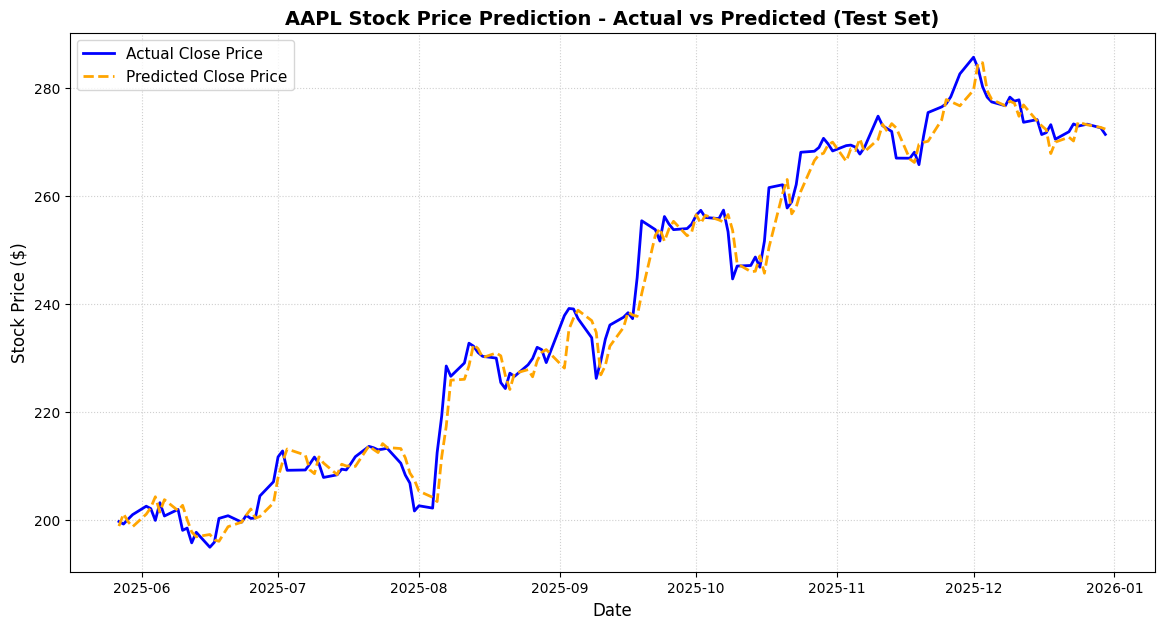

In [5]:
# Create a wide workspace canvas for our time-series plot
plt.figure(figsize=(14, 7))

# Plot the actual true closing prices from the test dataset (convert index to numpy array for clean plotting)
plt.plot(np.array(y_test.index), np.array(y_test), label="Actual Close Price", color="blue", linewidth=2)

# Plot the predicted closing prices generated by the machine learning model
plt.plot(np.array(y_test.index), np.array(predictions), label="Predicted Close Price", color="orange", linestyle="--", linewidth=2)

# Customize the chart layout to make it submission-ready
plt.title(f"{ticker} Stock Price Prediction - Actual vs Predicted (Test Set)", fontsize=14, fontweight='bold')
plt.xlabel("Date", fontsize=12)
plt.ylabel("Stock Price ($)", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle=":", alpha=0.6)

# Render the final chart directly inside your VS Code notebook
plt.show()

In [6]:
# Calculate evaluation metrics to quantify how well our model performed
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("--- Model Performance Metrics ---")
print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print(f"R-squared Score (R²): {r2:.4f}")

--- Model Performance Metrics ---
Mean Absolute Error (MAE): $2.45
R-squared Score (R²): 0.9851
